# Libraries

In [ ]:
# Dataset Librarie
import yfinance as yf

# Basic Machine Learning libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Sklearn libraries
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import BaggingRegressor, StackingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

## Import dataset

In [ ]:
ticker_symbol = "DX-Y.NYB"
ticker = yf.Ticker(ticker_symbol)
df = ticker.history(period="5y").reset_index(drop=False)
df.drop(['Volume','Dividends','Stock Splits'], axis=1, inplace=True)
df

,Date,Open,High,Low,Close
0,2020-11-02 00:00:00-05:00,93.889999,94.290001,93.889999,94.050003
1,2020-11-03 00:00:00-05:00,94.050003,94.050003,93.290001,93.550003
2,2020-11-04 00:00:00-05:00,93.089996,94.300003,93.089996,93.410004
3,2020-11-05 00:00:00-05:00,93.339996,93.550003,92.489998,92.529999
4,2020-11-06 00:00:00-05:00,92.570000,92.820000,92.180000,92.230003
...,...,...,...,...,...
1253,2025-10-27 00:00:00-04:00,98.839996,99.000000,98.730003,98.779999
1254,2025-10-28 00:00:00-04:00,98.750000,98.949997,98.570000,98.690002
1255,2025-10-29 00:00:00-04:00,98.739998,99.360001,98.620003,99.220001
1256,2025-10-30 00:00:00-04:00,99.139999,99.720001,98.919998,99.529999


## Task 1
Create a single line plot with the y-axis the value of each column (open, high, low, close) and the x-axis the date. Use the plotly library https://plotly.com/python/line-charts/ to support zooming in on the graph. Also enlarge the graph to make it clearer.

In [ ]:
# Store only feature column names(remove target value)
feature_names = df.drop('Date', axis=1).columns

# Plot the line for every feature for date values
fig = px.line(df, x="Date", y=feature_names, title='Dollar price over the last 5 years')
fig.show()

## Task 2
From the line plot of question (1), do you notice whether the time series are stationary or non-stationary? Justify.

### Answer: From the line plot of question (1), do you notice whether the time series are stationary or non-stationary? Justify.

**The time series are non-stationary:**

Line plot provides different scales between different years. The mean of the values is changing with the passage of time and also there is a large variation by looking at the lines for every feture.
- From 2021 to 2022 line plot increase
- From 2022 to 2023 line plot decrease
- From 2023 to 2025 line plot shows a local stationarity

## Task 3
Suppose we are training a Regressor on non-stationary time series. What would be the possible problems? Justify based on the specific data.

### Answer: Suppose we are training a Regressor on non-stationary time series. What would be the possible problems? Justify based on the specific data.

Regressor models are working better with stationary time series. The reason why there will be possible problems is:
- High variance: Across different dates variance is changing dramatically meaning that regressor model cannot be stable to its predictions
- Mean is changing: Mean value also changes in different dates. There are trends also by looking at the plot.

All these reasons will lead to overfitting/underfitting because model will not be able to generalize well since moving into the time series there is a trend up and trend down across different dates.

There is a high possibility the model to learn how to predict specific periods but it will fail when the variance will change.

## Task 4
What do you observe about the trend of the dollar between June and July 2025? Look for and list the possible causes that explain this trend.

### Answer: What do you observe about the trend of the dollar between June and July 2025? Look for and list the possible causes that explain this trend.

1) Price value decreases from June to July of 2025. This happens first of all because of the Federal Reserve monetary policy. Many investors change direction since they got scared of interest rates decrease from Fed [Falling Dollar: What Are the Consequences for the Global Monetary Landscape?](https://www.iris-france.org/en/falling-dollar-what-are-the-consequences-for-the-global-monetary-landscape/?utm_source=chatgpt.com)

2) Least important but also had a role in this result is that there was a reduced demand for American assets from investors [Currencies Focus July 2025](https://wealthmanagement.bnpparibas/lu/en/insights/market-analysis-/market-strategy/currencies-focus-july-2025.html?utm_source=chatgpt.com)



## Task 5
Is it possible to predict the price (close) of the dollar for the next day, if we have as information today's open, high, low, close? Alternatively, is it possible to find a function f(o_t,h_t,l_t,c_t )=c_(t+1)? Justify.

### Asnswer: Is it possible to predict the price (close) of the dollar for the next day, if we have as information today's open, high, low, close? Alternatively, is it possible to find a function f(o_t,h_t,l_t,c_t )=c_(t+1)? Justify.

Since there is a high variance over the years it is a difficult to answer this question but there is an observation: time series of the dollar might be stationary from 2023 to 2025, because values are around 100 with some variations. Τhis can be a local stationarity or an illusion. Model might provide accurate prediction for 2026 but if the trend changes then it will fail.

Referring to the previous question data changes from external factors. As a result it is not possible to find a

$$
f(o_t, h_t, l_t, c_t) = c_{t+1}
$$

which the model can use to predict the 'close' of the next day.

## Task 6
Does it make sense to randomly split the data into train-test? Justify.



### Answer: Does it make sense to randomly split the data into train-test? Justify.

Since there are changes from external factors it is not usefull to randomly split the dataset. These 4 features as an input cannot help the performance. There are no insights for the model to realize the reason why in some years the value of the dollar is getting lower and why bigger. By splitting random the dataset the model can get data from 2021 and 2025 were there was different periods with different situations in the world. As a result accuracy will be extremely low and the model not usufull for future predictions.

## Task 7
Split the dataset into train-test dataframes where train is all data before 2024 and test is all data from 2024. Then, remove the Date column from each DataFrame.

In [ ]:
# Get data
before_2024 = df[df["Date"]<"2024-01-01"].drop('Date', axis=1) # Data only before 2024 (Drop Date)
data_2024 = df[(df["Date"]>="2024-01-01")&(df["Date"]<"2025-01-01")].drop('Date', axis=1) # Data only from 2024 (Drop Date)

# Initialize x_training
X_train = before_2024
X_test = data_2024

## Task 8
Create a function that will take as an argument a dataframe (either train or test), as well as a parameter N and will return 2 numpy arrays: Inputs (x) and Targets (y), where x are the timeframes and y are the close value of the next days. The timeframes are a set of N consecutive rows. For example if N=3, then the timeframes would be 3x4 arrays, where 3 are the rows and 4 are the open, high, low, close attributes. For N size, the 1st Timeframe would include the rows x_0: [0,N-1], the 2nd x_1: [1,N], the 3rd x_2: [2,N+1], etc. For the targets, y_0 would be the corresponding c_N, y_1, C_(N+1), etc. For the Targets you can use the pandas shift command.

### Answer: Code explanation

- Make a function get_timeframes getting a Data Frame and a number.
- Initialize two list to store the data for input x and target y
- Calculate the x,y as requested
- Append results into the lists to combine all together into np arrays
- Return x timeframes and y close value of next day

In [ ]:
def get_timeframes(df, n):
  # Initialize lists
  x = []
  y = []

  for i in range(len(df) - n):

    # Get values
    frame = df.iloc[i:n+i].to_numpy()
    target = df['Close'].iloc[n+i]

    # Append values in lists
    x.append(frame)
    y.append(target)

  # Convert to np arrays
  X = np.array(x)
  y = np.array(y)

  return X,y

# Test to ensure it is working
xx, yy = get_timeframes(X_test, 3)
print("First timeframe for test set with N = 3:\n",xx[0])
print("-"*40)
print("Next day close value:\n",yy[0])

First timeframe for test set with N = 3:
 [[101.41999817 102.25       101.33999634 102.19999695]
 [102.15000153 102.73000336 102.08000183 102.45999908]
 [102.45999908 102.52999878 102.15000153 102.41999817]]
----------------------------------------
Next day close value:
 102.41000366210938


## Task 9
If we want to predict the next day, should the size of the timeframe N be small or large? What do you suggest for the size of N if we want to predict a longer horizon (e.g. one month)? Please justify.

### Answer: If we want to predict the next day, should the size of the timeframe N be small or large? What do you suggest for the size of N if we want to predict a longer horizon (e.g. one month)? Please justify.

If we want to predict the next day then the timeframe must be small because it is important to have as recent information as possible. The world's data changes day by day and for that reason if we want to predict the next day and get prediction as close to the real one it is important to have new data instead of old data. Old data (such as 5 weeks ago until now) may be a result of circumstances which does not exist in nowadays and so the model will provide a false outcome.

On the other hand, if we want to predict a longer horizon, the timeframe changes scale since it is important to realize bigger scale path of the data. Data have different behavior in bigger scale showing a different pattern rather than getting smaller N. Bigger N also will help to get the overall decision on how the data behavior. Also it is important to mention not to use extremely huge N since it is important, the data not to be to old.

## Task 10
Create x_train, y_train, x_test, y_test by setting N to 5. Since the machine learning models we will use accept vectors as their inputs, convert the input arrays to vectors of size Nx4, i.e. 20. You can use the numpy reshape command https://numpy.org/doc/stable/reference/generated/numpy.reshape.html Check that the number of inputs is the same as the number of targets. Check that the preprocessing was done correctly by printing the 1st input of x_train.

### Answer: Code explanation
- Call get_timeframes to create test and train values for x, y
- To create vectors for x_train and x_test call reshape to flatten the train

  np.array from (794, 5, 4) --> (794, 20) and
  test np array from (247, 5, 4) --> (247, 20)

- Print results to ensure everything is working fine

In [ ]:
# Initialize n = 5
n = 5

# Get values for x,y train (N = 5)
x_train, y_train = get_timeframes(df=X_train, n=n)
x_train = x_train.reshape(x_train.shape[0], n*4) # Convert x_train to vector

# Get values for x,y test (N = 5)
x_test, y_test = get_timeframes(df=X_test, n=n)
x_test = x_test.reshape(x_test.shape[0], n*4) # Convert x_test to vector

# Print result to ensure everything went well
print("x_train shape: ", x_train.shape)
print("y_train shape: ", y_train.shape)
print("-"*50)
print("x_test shape: ",x_test.shape)
print("y_test shape: ",y_test.shape)
print("-"*50)
print("First x_train[0] --> ", x_train[0])


x_train shape:  (790, 20)
y_train shape:  (790,)
--------------------------------------------------
x_test shape:  (247, 20)
y_test shape:  (247,)
--------------------------------------------------
First x_train[0] -->  [93.88999939 94.29000092 93.88999939 94.05000305 94.05000305 94.05000305
 93.29000092 93.55000305 93.08999634 94.30000305 93.08999634 93.41000366
 93.33999634 93.55000305 92.48999786 92.52999878 92.56999969 92.81999969
 92.18000031 92.23000336]


## Task 11
 Train the following models in train and calculate the MAE in train and test:
1) Linear Regressor
2) Random Forest Regressor
3) Bagging using as estimator: Linear Regression
4) Boosting applying XG-Boost
5) Stacking using as estimator: Linear Regression

In [ ]:
# Initialize estimators
stack_estimators = [
    ('tree', DecisionTreeRegressor()),
    ('lr', LinearRegression())
]

# Make a list with models and parameters
models = [LinearRegression(),
          RandomForestRegressor(),
          BaggingRegressor(estimator=LinearRegression()),
          XGBRegressor(),
          StackingRegressor(
              estimators=stack_estimators,
              final_estimator=LinearRegression())]

# Initialize the mae list to store mae results of every model
mae_list = []

for model in models:
  # train model
  model.fit(x_train, y_train)

  # get predictions for train set
  y_train_pred = model.predict(x_train)
  # get mae for train set
  mae_train = mean_absolute_error(y_train, y_train_pred)

  # get predictions for test set
  y_test_pred = model.predict(x_test)
  # get mae for test set
  mae_test = mean_absolute_error(y_test, y_test_pred)

  mae_list.append({
      "model_name": model.__class__.__name__,
      "mae_train": mae_train,
      "mae_test": mae_test
  })

# Convert to df for better visualization
mae_df = pd.DataFrame(mae_list)
mae_df

,model_name,mae_train,mae_test
0,LinearRegression,0.345311,0.284328
1,RandomForestRegressor,0.147588,0.319394
2,BaggingRegressor,0.346311,0.287560
3,XGBRegressor,0.024595,0.399892
4,StackingRegressor,0.363091,0.290408


### Answer: Code explanation
To create only one plot it is essential to use subplots and combine them into one. This can happen with plt.subplots and create a barplot for train and test mae. Adding a little details such as the color, a rotation and legend to make plot better to be read.

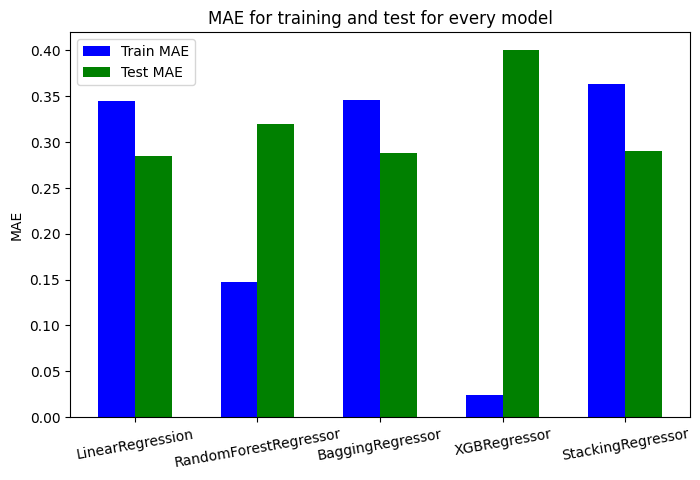

In [ ]:
# Initialize width and x
w, x = 0.3, np.arange(len(mae_df))

# Create a fig
fig, ax = plt.subplots(figsize=(8,5))

# Create bar plot for train and test set (set colors to blue for train and green for test as it was requested)
ax.bar(x - w/2, mae_df['mae_train'], width=w, color='blue', label='Train MAE')
ax.bar(x + w/2, mae_df['mae_test'], width=w, color='green', label='Test MAE')

# Stick model names to their bars
ax.set_xticks(x)
ax.set_xticklabels(mae_df['model_name'], rotation=10) # Adding rotation to avoid text overlapping
ax.set_ylabel('MAE')
ax.set_title('MAE for training and test for every model')
# Set the table names up and left
ax.legend()

plt.show()

### Answer: Finally, briefly explain (1-2 lines) how each model (Regressor) works.

1) LinearRegression: Creates a linear connection with input data and with the output. It is good for linear relationships. It doesn't work for non linear relationships. MAE calculates the square of the distance between predicted and real value.
2) RandomForestRegressor: Creates multiple trees with the same dataset but data are randomly taken. Predict by getting the average of its predictions. Encounters overfitting/underfitting
3) BaggingRegressor: Applies bootsrap aggregation by training many sub-models in different samples of dataset and combining the average of the results
4) XGBRegressor: Creates linear decision trees where every new tree is the updated version of previous by fixing the mistakes of the previous trees using gradient boosting optimizer.
5) StackingRegressor: Combines different models using Linear Regression model as the final model to learn how to combine the prediction by getting only the advantages of the every model seperatly.

## Task 12
You will try to improve the accuracy of the models in the following ways:
1) For each record of the data, extract the month and day as additional features. (Use the Date column from the original dataset). State why the month might help improve the predictions.
2) For each column y={Open,High,Low,Close,Volume}, apply the Log Returns formula:
$$
y_t = \ln\left(\frac{y_{t+1}}{y_t}\right)
$$
3) Create a histogram for each column and explain how the above formula might improve the models' forecasts.
4) If a model predicts C_(t+1)=0.01, what does this mean for the Close value? Furthermore, if the value C_t=0.95$, what will be the absolute value C_(t+1) according to the above prediction?
5) Repeat the process 7🡪9🡪10.

### Answer (1):  State why the month might contribute to improving the forecasts

By adding the month into the dataset the model can extract observations about feature connection that might couldn't catch without this extra detail. The month feature will help the model to detects seasonality into the values. This detail will help also the model to generalize better for long and short periods regarding the task.

In [ ]:
df['Week'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df

,Date,Open,High,Low,Close,Week,Day
0,2020-11-02 00:00:00-05:00,93.889999,94.290001,93.889999,94.050003,11,2
1,2020-11-03 00:00:00-05:00,94.050003,94.050003,93.290001,93.550003,11,3
2,2020-11-04 00:00:00-05:00,93.089996,94.300003,93.089996,93.410004,11,4
3,2020-11-05 00:00:00-05:00,93.339996,93.550003,92.489998,92.529999,11,5
4,2020-11-06 00:00:00-05:00,92.570000,92.820000,92.180000,92.230003,11,6
...,...,...,...,...,...,...,...
1253,2025-10-27 00:00:00-04:00,98.839996,99.000000,98.730003,98.779999,10,27
1254,2025-10-28 00:00:00-04:00,98.750000,98.949997,98.570000,98.690002,10,28
1255,2025-10-29 00:00:00-04:00,98.739998,99.360001,98.620003,99.220001,10,29
1256,2025-10-30 00:00:00-04:00,99.139999,99.720001,98.919998,99.529999,10,30


### Answer (2)
For each column y={Open,High,Low,Close,Volume}, apply the Log Returns formula:
$$
y_t = \ln\left(\frac{y_{t+1}}{y_t}\right)
$$

In [ ]:
# Import again dataset to have volume column
# df_v = ticker.history(period="5y").reset_index(drop=False)
# df_v.drop(['Volume','Dividends','Stock Splits'], axis=1, inplace=True)
columns = ['Open','High','Low','Close']

# Apply formula in columns 'Open','High','Low','Close','Volume' and create new column with new values
for col in columns:
  df[col+"_log_returns"] = np.log(df[col].shift(-1)/df[col])
# df.drop(columns=columns, inplace=True)

In [ ]:
df

,Date,Open,High,Low,Close,Week,Day,Open_log_returns,High_log_returns,Low_log_returns,Close_log_returns
0,2020-11-02 00:00:00-05:00,93.889999,94.290001,93.889999,94.050003,11,2,0.001703,-0.002549,-0.006411,-0.005331
1,2020-11-03 00:00:00-05:00,94.050003,94.050003,93.290001,93.550003,11,3,-0.010260,0.002655,-0.002146,-0.001498
2,2020-11-04 00:00:00-05:00,93.089996,94.300003,93.089996,93.410004,11,4,0.002682,-0.007985,-0.006466,-0.009466
3,2020-11-05 00:00:00-05:00,93.339996,93.550003,92.489998,92.529999,11,5,-0.008284,-0.007834,-0.003357,-0.003247
4,2020-11-06 00:00:00-05:00,92.570000,92.820000,92.180000,92.230003,11,6,-0.003571,0.001507,-0.000543,0.005407
...,...,...,...,...,...,...,...,...,...,...,...
1253,2025-10-27 00:00:00-04:00,98.839996,99.000000,98.730003,98.779999,10,27,-0.000911,-0.000505,-0.001622,-0.000911
1254,2025-10-28 00:00:00-04:00,98.750000,98.949997,98.570000,98.690002,10,28,-0.000101,0.004135,0.000507,0.005356
1255,2025-10-29 00:00:00-04:00,98.739998,99.360001,98.620003,99.220001,10,29,0.004043,0.003617,0.003037,0.003119
1256,2025-10-30 00:00:00-04:00,99.139999,99.720001,98.919998,99.529999,10,30,0.003564,-0.001877,0.005002,-0.000201


### Answer (3)
Create a histogram for each column and explain how the above formula will potentially improve the models' predictions.

By using this formula features converted into percentage changes between consecutive days. Because of that model will have more stable variance and better stationary regarding the time serie. Using these features helpful for model prediction will also help the model to learn relationships between model easier.

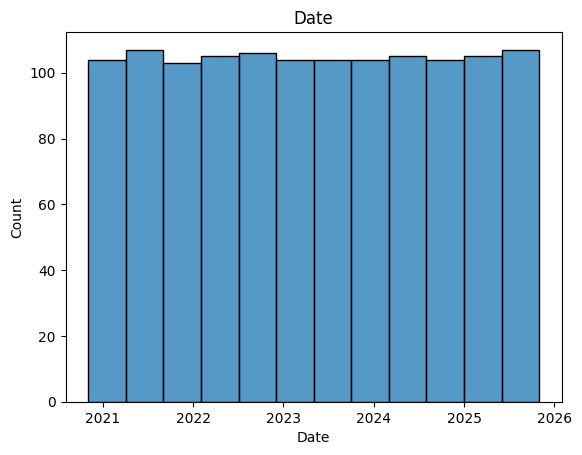

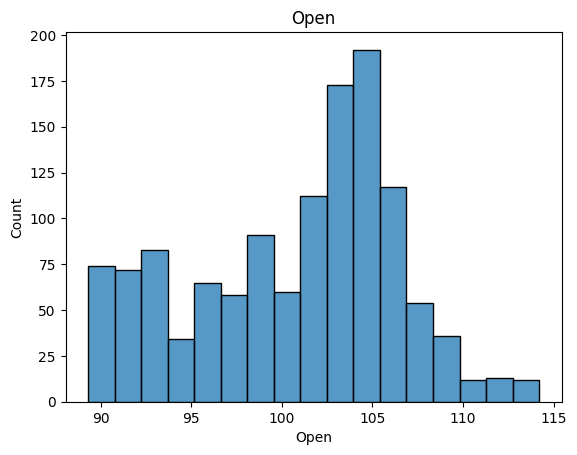

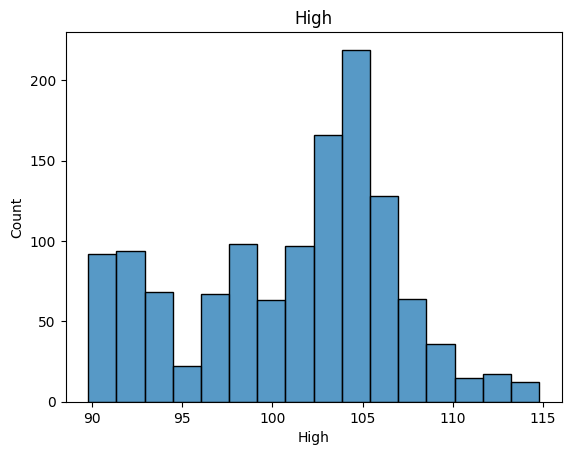

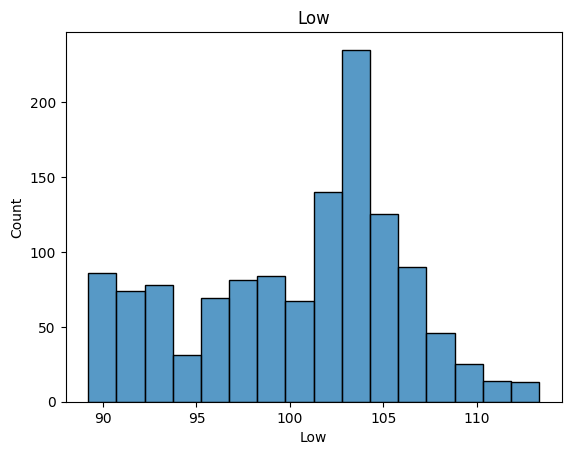

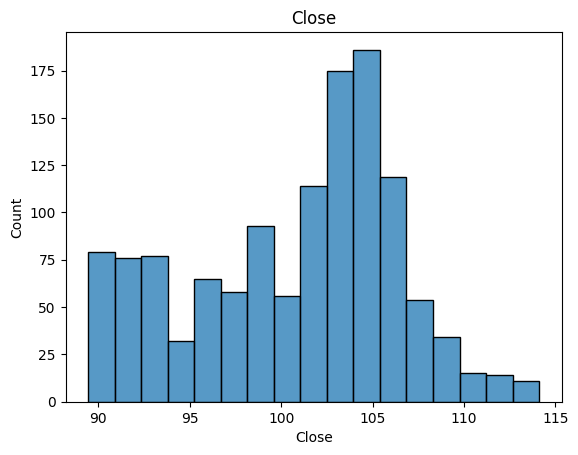

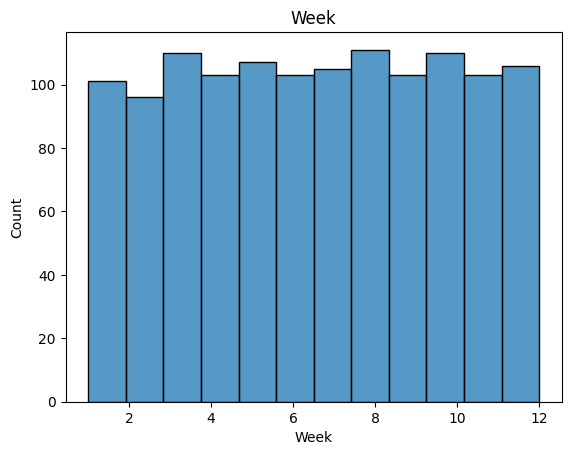

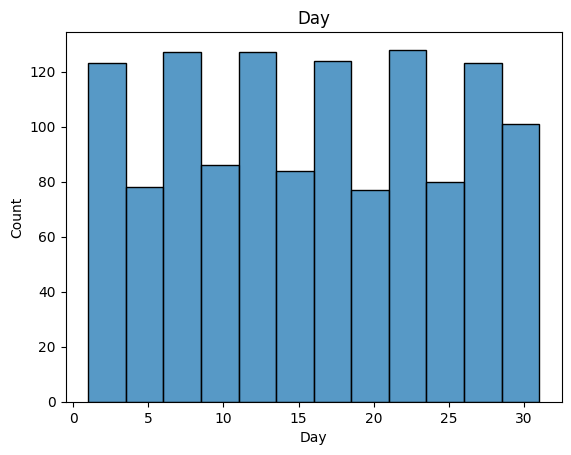

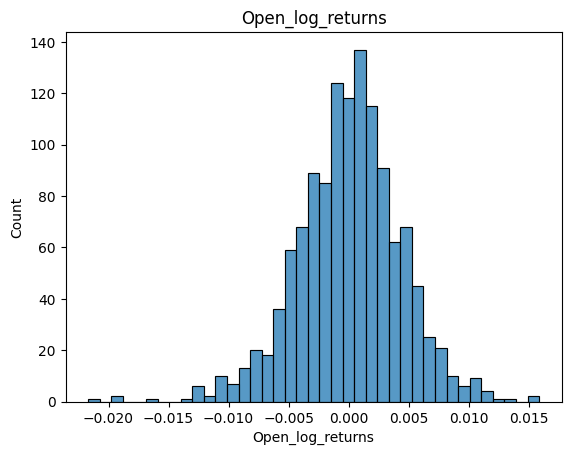

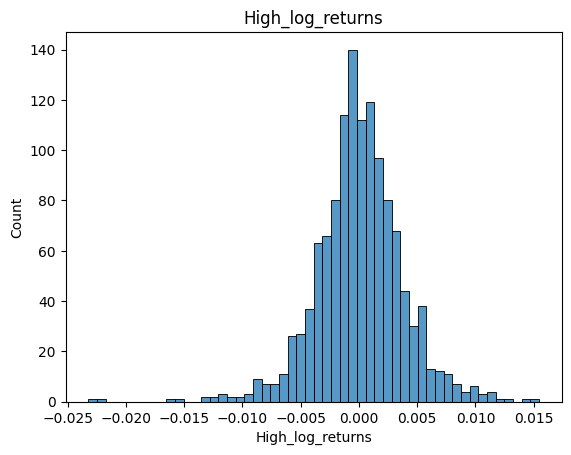

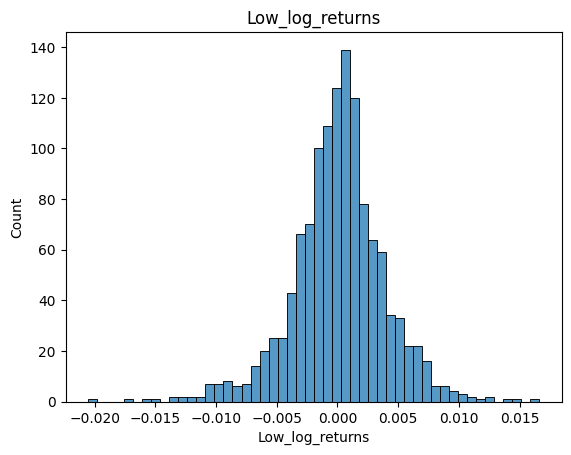

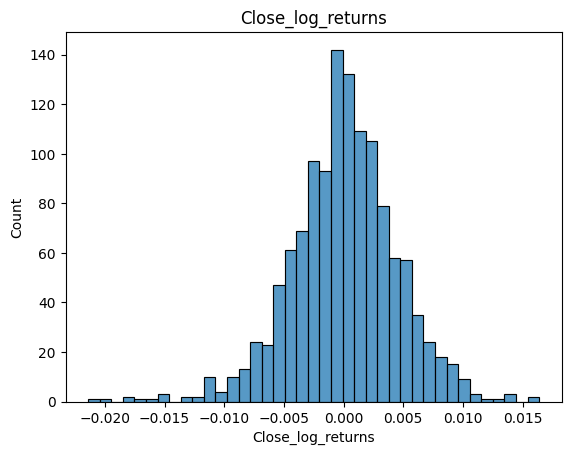

In [ ]:
# For every feature plot the histogram
for col in df.columns:
  sns.histplot(df, x=col)
  plt.title(col)
  plt.show()

### Answer (4)
**If a model predicts C_{t+1}=0.01, what does this mean for the Close price?**

Thinking that Ct+1 is the log returns then yt+1 = 0.01. Changing the a bit the math formula from
$$
y_t = \ln\left(\frac{y_{t+1}}{y_t}\right)
$$

to
$$
r_{t+1} = 0.01 \Rightarrow \frac {C_{t+1}}{C_t} = e^{0.01} \approx 1.01005
$$

Stock exchange is awaiting for a 1.01005% 'close' price ascent for the next day.

---
**Furthermore, if C_t=0.95$,  what will be the absolute value of C_(t+1) according to the above prediction?:**

First things first reaplce C_t into the formula and calculate to find Ct+1
$$
C_{t+1} = C_t \cdot e^{0.01} = 0.95 \times 1.01005 = 0.95955
$$

**Final Answer:**  
$$ C_{t+1} \approx 0.9596 $$


### Answer (5)
Repeat process 7🡪9🡪10.

In [ ]:
# Get data
before_2024 = df[df["Date"]<"2024-01-01"].drop('Date', axis=1) # Data only before 2024 (Drop Date)
data_2024 = df[(df["Date"]>="2024-01-01")&(df["Date"]<"2025-01-01")].drop('Date', axis=1) # Data only from 2024 (Drop Date)


In [ ]:
def get_timeframes(df, n):
  # Initialize lists
  x = []
  y = []

  for i in range(len(df) - n):

    # Get values
    frame = df.iloc[i:n+i].to_numpy()
    target = df['Close_log_returns'].iloc[n+i]

    # Append values in lists
    x.append(frame)
    y.append(target)

  # Convert to np arrays
  X = np.array(x)
  y = np.array(y)

  return X,y

# # Test to ensure it is working
# xx, yy = get_timeframes(X_test, 3)
# print("First timeframe for test set with N = 3:\n",xx[0])
# print("-"*40)
# print("Next day close value:\n",yy[0])

In [ ]:
# Initialize x_training
X_train = before_2024
X_test = data_2024

# Initialize n = 5
n = 5

# Get values for x,y train (N = 5)
x_train, y_train = get_timeframes(df=X_train, n=n)
x_train = x_train.reshape(x_train.shape[0], n*len(data_2024.columns)) # Convert x_train to vector

# Get values for x,y test (N = 5)
x_test, y_test = get_timeframes(df=X_test, n=n)
x_test = x_test.reshape(x_test.shape[0], n*len(data_2024.columns)) # Convert x_test to vector

# Print result to ensure everything went well
print("x_train shape: ", x_train.shape)
print("y_train shape: ", y_train.shape)
print("-"*50)
print("x_test shape: ",x_test.shape)
print("y_test shape: ",y_test.shape)
print("-"*50)
print("First x_train[0] --> ", x_train[0])


x_train shape:  (790, 50)
y_train shape:  (790,)
--------------------------------------------------
x_test shape:  (247, 50)
y_test shape:  (247,)
--------------------------------------------------
First x_train[0] -->  [ 9.38899994e+01  9.42900009e+01  9.38899994e+01  9.40500031e+01
  1.10000000e+01  2.00000000e+00  1.70271043e-03 -2.54856099e-03
 -6.41094698e-03 -5.33050285e-03  9.40500031e+01  9.40500031e+01
  9.32900009e+01  9.35500031e+01  1.10000000e+01  3.00000000e+00
 -1.02598604e-02  2.65463381e-03 -2.14620300e-03 -1.49764025e-03
  9.30899963e+01  9.43000031e+01  9.30899963e+01  9.34100037e+01
  1.10000000e+01  4.00000000e+00  2.68197350e-03 -7.98513666e-03
 -6.46622032e-03 -9.46554202e-03  9.33399963e+01  9.35500031e+01
  9.24899979e+01  9.25299988e+01  1.10000000e+01  5.00000000e+00
 -8.28358951e-03 -7.83395482e-03 -3.35731687e-03 -3.24740942e-03
  9.25699997e+01  9.28199997e+01  9.21800003e+01  9.22300034e+01
  1.10000000e+01  6.00000000e+00 -3.57125898e-03  1.50715273e-03


In [ ]:
# Initialize estimators
stack_estimators = [
    ('lr', LinearRegression()),
    ('xgb', XGBRegressor())
]

# Make a list with models and parameters
models = [LinearRegression(),
          RandomForestRegressor(),
          BaggingRegressor(estimator=LinearRegression()),
          XGBRegressor(),
          StackingRegressor(
              estimators=stack_estimators,
              final_estimator=LinearRegression())]

# Initialize the mae list to store mae results of every model
mae_list = []

for model in models:
  # train model
  model.fit(x_train, y_train)

  # get predictions for train set
  y_train_pred = model.predict(x_train)
  # get mae for train set
  mae_train = mean_absolute_error(y_train, y_train_pred)

  # get predictions for test set
  y_test_pred = model.predict(x_test)
  # get mae for test set
  mae_test = mean_absolute_error(y_test, y_test_pred)

  mae_list.append({
      "model_name": model.__class__.__name__,
      "mae_train": mae_train,
      "mae_test": mae_test
  })

# Convert to df for better visualization
mae_df = pd.DataFrame(mae_list)
mae_df


,model_name,mae_train,mae_test
0,LinearRegression,0.003347,0.002949
1,RandomForestRegressor,0.001337,0.002837
2,BaggingRegressor,0.003378,0.002981
3,XGBRegressor,0.000512,0.003247
4,StackingRegressor,0.003256,0.002748


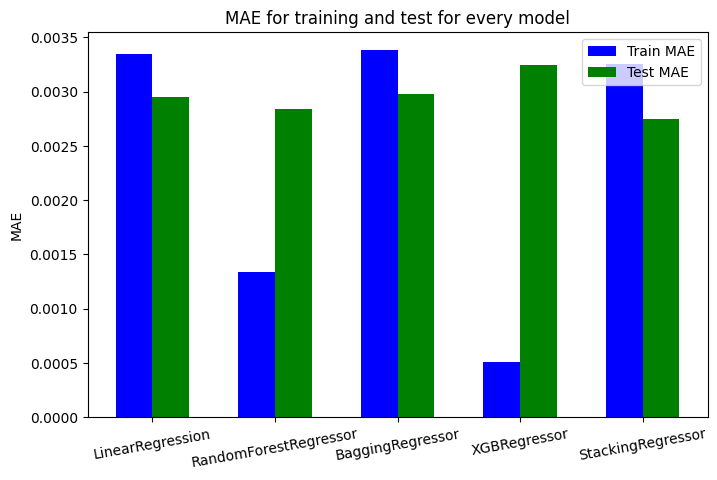

In [ ]:
# Initialize width and x
w, x = 0.3, np.arange(len(mae_df))

# Create a fig
fig, ax = plt.subplots(figsize=(8,5))

# Create bar plot for train and test set (set colors to blue for train and green for test as it was requested)
ax.bar(x - w/2, mae_df['mae_train'], width=w, color='blue', label='Train MAE')
ax.bar(x + w/2, mae_df['mae_test'], width=w, color='green', label='Test MAE')

# Stick model names to their bars
ax.set_xticks(x)
ax.set_xticklabels(mae_df['model_name'], rotation=10) # Adding rotation to avoid text overlapping
ax.set_ylabel('MAE')
ax.set_title('MAE for training and test for every model')
# Set the table names up and left
ax.legend()

plt.show()

## Task 13
Then, Train Lasso Regressor (Lasso Regressor) and display the absolute values ​​of the coefficients. Which features are the 10 most important and which days of the timeframe do they correspond to? Justify. Is there any day that contributes more to the estimation of the forecasts for timestep t+1?

In [ ]:
# Initialize lasso model
model_las = Lasso(alpha=0.00000001)
model_las.fit(X=x_train, y=y_train)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.857e-03, tolerance: 1.665e-06



Lasso(alpha=1e-08)

### Graph explanation:

| Pointers| Days          | Example of features         |
| ------- | --------------| ----------------------------|
| 0–8     | 1 Day (t–5)   | Open, High, Low, Close, ... |
| 9–17    | 2 Day (t–4)   | Open, High, Low, Close, ... |
| 18–26   | 3 Day (t–3)   | Open, High, Low, Close, ... |
| 27–35   | 4 Day (t–2)   | Open, High, Low, Close, ... |
| 36–44   | 5 Day (t–1)   | Open, High, Low, Close, ... |


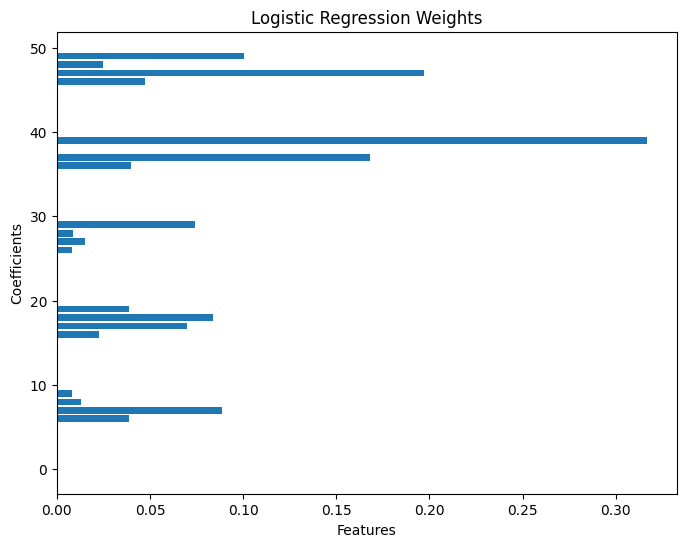

In [ ]:
# Make prediction and get Mean
coeffs = model_las.coef_
importance_weights = np.abs(coeffs)

plt.figure(figsize=(8,6))
plt.barh(range(len(importance_weights)), importance_weights)
plt.title('Logistic Regression Weights')
plt.xlabel('Features')
plt.ylabel('Coefficients')
plt.show()

### Answer: Which features are the 10 most important and which days of the timeframe do they correspond to?

From coefficients we can get the day and the features with the highest importance. By looking at the results return_log_close has the highest influence every day. Return_log_high is getting the second most important feature followed by the return_log_open which has the least importance in day 1.

---
### Answer: Is there any day that contributes more to the estimation of the forecasts for timestep t+1?

Yes there are specific days that contributes more to the estimation of the forecassts. Day 4 and 5 (t-1, t-2) contributes the most because of the high values of absolute value of coefficient is located to this day. This authenticates that the model lay more on recent values to predict the next day.

In [ ]:
# Get the ten most important features from importance of weights list initilized before
ten_most_important = np.argsort(importance_weights)[-10:][::-1] # returns the indices that would sort an array

print("Ten most important features:")
print("-"*35)
# For every value get the day and the feature name
for i in ten_most_important:
  day = i // len(data_2024.columns) + 1
  feature = data_2024.columns[i%len(data_2024.columns)]
  print(f"Day: {day} | Feature: {feature} \nCoefficient: {importance_weights[i]}")
  print("-"*35)

Ten most important features:
-----------------------------------
Day: 4 | Feature: Close_log_returns 
Coefficient: 0.3169980895447186
-----------------------------------
Day: 5 | Feature: High_log_returns 
Coefficient: 0.19726206673281246
-----------------------------------
Day: 4 | Feature: High_log_returns 
Coefficient: 0.16815466013645713
-----------------------------------
Day: 5 | Feature: Close_log_returns 
Coefficient: 0.10056082801013827
-----------------------------------
Day: 1 | Feature: High_log_returns 
Coefficient: 0.08887138814339167
-----------------------------------
Day: 2 | Feature: Low_log_returns 
Coefficient: 0.08406647731537355
-----------------------------------
Day: 3 | Feature: Close_log_returns 
Coefficient: 0.07419340274543684
-----------------------------------
Day: 2 | Feature: High_log_returns 
Coefficient: 0.06985118393286374
-----------------------------------
Day: 5 | Feature: Open_log_returns 
Coefficient: 0.047206345503624625
------------------------

### Task 14
Create a line-plot with the lasso predictions (y_pred) and the actual values ​​of C_(t+1). Note: You will need to convert logarithmic returns to absolute values.

In [ ]:
# Make Lasso predictions
y_pred = model_las.predict(x_test)
y_true = y_test

# Get the next value --> C(t+1)
y_test_len = len(y_test)
C_t = X_test['Close'].iloc[-y_test_len:].values

# Convert logarithmic returns to absolute values
y_pred = C_t * np.exp(y_pred)
y_true = C_t * np.exp(y_true)

### Line Plot


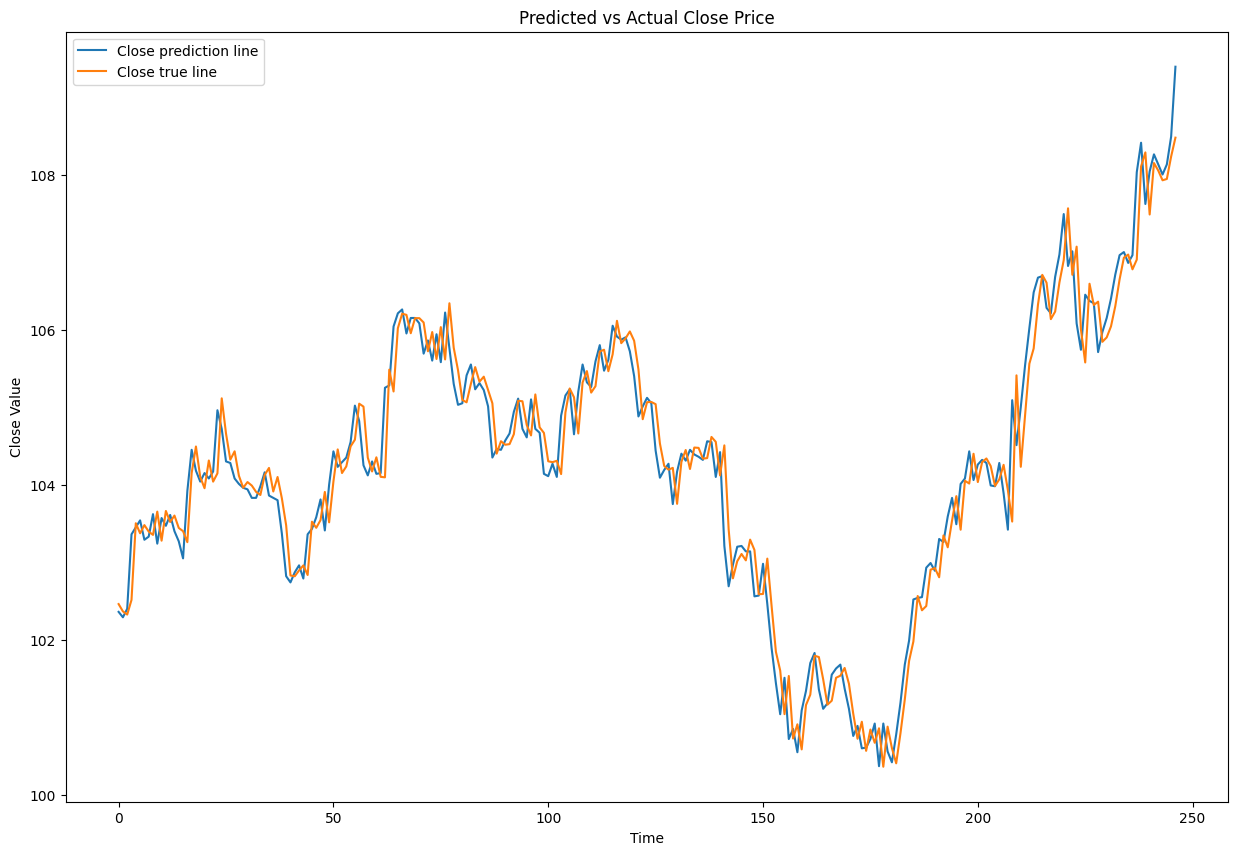

In [ ]:
plt.figure(figsize=(15,10))
plt.plot(y_true, label='Close prediction line')
plt.plot(y_pred, label='Close true line')
plt.title('Predicted vs Actual Close Price')
plt.xlabel('Time')
plt.ylabel('Close Value')
plt.legend()
plt.show()
